# El entrenamiento de Naruto Uzumaki

Naruto Uzumaki dispone de poco tiempo para subir  de  nivel  su  técnica  Rasengan  antes  de que  llegue la  siguiente  amenaza  a  la  aldea. 
Para acelerar el proceso de entrenamiento utilizará su Jutsu Multi Clones de Sombra, permitiendo  que  cada  clon  realice  una  parte del  entrenamiento  y  al  final  Naruto  incorpore el avance de cada clon como propio.  

**<u>Sobre los clones se sabe lo siguiente:</u>**
* La cantidad de Chakra (energía) para entrenar es variable (5 a 10 unidades). 
* Al consumir todo el Chakra el clon desaparece finalizando su sesión de entrenamiento.  
* La sesión de entrenamiento de cada clon se compone  de  varios  intentos  (uno  por  cada unidad de Chakra).  
* La duración de un intento es variable (100 a 200 milisegundos).  
* Cada  intento  puede  salir  bien  (se  sube  un punto  de  nivel)  o  salir  mal  (no  se  sube  de nivel). Hay una probabilidad del 0.5 de subir de nivel. 

**<u>Se pide:</u>**
* Implementar un programa que simule el entrenamiento de Naruto utilizando programación concurrente a través de N hilos, permitiendo tomar el tiempo de ejecución.  
* No utilizar ningún mecanismo de comunicación ni sincronización entre los hilos. 
* Ejecutar el programa para distintas cantidades de clones (5, 10, 20, etc). Informando  el  tiempo  y  nivel  alcanzado  para cada ejecución. 
* Responda:  ¿Cuál  sería  la  cantidad  óptima  de clones? Justifique su respuesta.  
* Realizar  un  gráfico  de  tiempo  en  base  a  la cantidad de clones. 

Esta celda escribe el codigo de debajo en el archivo main.cpp

In [1]:
%%writefile main.cpp

#include <chrono>
#include <iostream>
#include <numeric>
#include <random>
#include <sstream>
#include <thread>
#include <vector>

namespace {

void EntrenarClon(int indice_clon, std::vector<int>& niveles_clones) {
  std::random_device fuente_semilla;
  std::mt19937 generador(fuente_semilla());
  std::uniform_int_distribution<int> dist_chakra(5, 10);
  std::uniform_int_distribution<int> dist_pausa_ms(100, 200);
  std::bernoulli_distribution dist_sube_nivel(0.5);

  int chakra = dist_chakra(generador);
  while (chakra-- > 0) {
    if (dist_sube_nivel(generador)) {
      ++niveles_clones[indice_clon];
    }
    std::this_thread::sleep_for(
        std::chrono::milliseconds(dist_pausa_ms(generador)));
  }
}

int Entrenar(int cantidad_clones) {
  std::vector<int> niveles_clones(cantidad_clones);
  {
    std::vector<std::jthread> clones;
    clones.reserve(cantidad_clones);
    for (int i = 0; i < cantidad_clones; ++i) {
      clones.emplace_back(EntrenarClon, i, std::ref(niveles_clones));
    }
  }
  return std::accumulate(niveles_clones.begin(), niveles_clones.end(), 0);
}

int ProcesarArgs(int argc, char* argv[]) {
  if (argc < 2) {
    std::cerr << "Falta argumento. Uso: " << argv[0] << " <cantidad_clones>\n";
    return -1;
  }
  std::stringstream ss(argv[1]);
  int value{};
  if (ss >> value) {
    return value;
  }
  std::cerr << "Error: '" << argv[1] << "' could not be parsed.\n";
  return -1;
}

}  // namespace

int main(int argc, char* argv[]) {
  const int cantidad_clones = ProcesarArgs(argc, argv);
  if (cantidad_clones != -1) {
    const auto inicio = std::chrono::steady_clock::now();
    const int nivel_alcanzado = Entrenar(cantidad_clones);
    const auto fin = std::chrono::steady_clock::now();
    const std::chrono::duration<double, std::milli> duracion = fin - inicio;
    std::cout << "Nivel alcanzado: " << nivel_alcanzado << "\n"
              << "Tiempo de ejecución: " << duracion.count() << " ms\n";
  }
  return 0;
}

Writing main.cpp


Esta celda compila el programa.

In [2]:
%%bash
g++ main.cpp -std=c++20 -o program

Ejecuta el programa. Recibe como parametro la cantidad de clones.

In [3]:
%%bash
./program 10000

Nivel alcanzado: 37561
Tiempo de ejecución: 2310.64 ms


### ¿Cuál  sería  la  cantidad  óptima  de clones? Justifique su respuesta. 

Siguiendo el grafico y las pruebas realizadas, encontramos que el tiempo de ejecucion comienza a duplicarse o casi triplicarse luego de los 10000 clones (hilos) lanzados. Si bien es cierto que el tiempo para los 20000 clones alcanza casi los 4 segundos, tambien lo es el hecho de que conseguimos el doble del nivel. Dado que la probabilidad de conseguir aumentar el nivel en un intento es de 0.5, no parece errado considerar que la mayor cantidad posible de clones a lanzar sera la cantidad optima de clones. Esta cantidad estara limitada por distintas variables dependiendo donde se corra el programa.

### Realizar  un  gráfico  de  tiempo  en  base  a  la cantidad de clones. 

Clones:      5 | Nivel:     24 | Tiempo:    1576.11 ms
Clones:     10 | Nivel:     35 | Tiempo:    1549.93 ms
Clones:     20 | Nivel:     82 | Tiempo:    1651.92 ms
Clones:     50 | Nivel:    176 | Tiempo:    1607.92 ms
Clones:    100 | Nivel:    386 | Tiempo:    1706.91 ms
Clones:    200 | Nivel:    772 | Tiempo:    1646.81 ms
Clones:    500 | Nivel:   1856 | Tiempo:    1759.72 ms
Clones:   1000 | Nivel:   3706 | Tiempo:    1720.78 ms
Clones:   2000 | Nivel:   7427 | Tiempo:    1825.25 ms
Clones:   5000 | Nivel:  18716 | Tiempo:    1954.26 ms
Clones:  10000 | Nivel:  37498 | Tiempo:    2329.97 ms
Clones:  20000 | Nivel:  75101 | Tiempo:    3976.37 ms


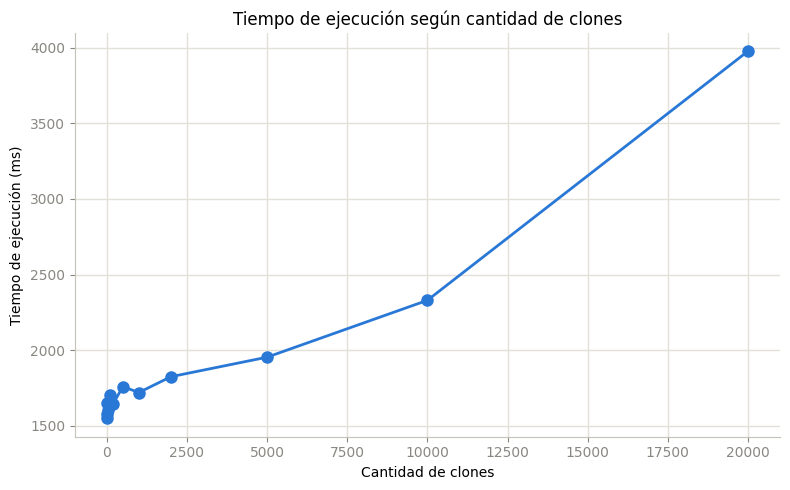

In [4]:
import re
import subprocess

import matplotlib.pyplot as plt

_CANTIDADES_CLONES = [5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
_PATRON_NIVEL = re.compile(r"Nivel alcanzado: (\d+)")
_PATRON_TIEMPO = re.compile(r"Tiempo de ejecución: ([\d.]+) ms")


def graficar_resultados(cantidades: list[int], tiempos: list[float]) -> None:
    """Genera y muestra el gráfico de tiempo de ejecución vs cantidad de clones.

    Args:
        cantidades: Lista con las cantidades de clones utilizadas.
        tiempos: Lista con los tiempos de ejecución en milisegundos correspondientes.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        cantidades,
        tiempos,
        marker="o",
        markersize=8,
        linewidth=2,
        color="#2a78d6",
    )
    ax.set_xlabel("Cantidad de clones")
    ax.set_ylabel("Tiempo de ejecución (ms)")
    ax.set_title("Tiempo de ejecución según cantidad de clones")
    ax.grid(True, color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#c3c2b7")
        
    ax.tick_params(colors="#898781")
    plt.tight_layout()
    plt.show()


def main() -> None:
    """Ejecuta el programa externo iterativamente y recolecta las métricas."""
    tiempos_ms: list[float] = []
    niveles: list[int] = []
    cantidades_exitosas: list[int] = []

    for cantidad in _CANTIDADES_CLONES:
        try:
            resultado = subprocess.run(
                ["./program", str(cantidad)], 
                capture_output=True, 
                text=True, 
                check=True
            )
        except subprocess.CalledProcessError as e:
            print(f"Error al ejecutar el programa con {cantidad} clones: {e}")
            continue

        match_nivel = _PATRON_NIVEL.search(resultado.stdout)
        match_tiempo = _PATRON_TIEMPO.search(resultado.stdout)

        if match_nivel and match_tiempo:
            nivel = int(match_nivel.group(1))
            tiempo = float(match_tiempo.group(1))
            
            niveles.append(nivel)
            tiempos_ms.append(tiempo)
            cantidades_exitosas.append(cantidad)
            
            print(
                f"Clones: {cantidad:>6} | Nivel: {nivel:>6} | "
                f"Tiempo: {tiempo:>10.2f} ms"
            )
        else:
            print(f"Advertencia: No se pudo parsear la salida para {cantidad} clones.")

    graficar_resultados(cantidades_exitosas, tiempos_ms)


if __name__ == "__main__":
    main()